In [2]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

import _helper_grammar_functions as jsgo
import _syntax_score_helper_function as ga
from _helper_functions import *

# Assign syntax features to elements

In [3]:

rep=1

# load syntax features
fn=f'F05-Syntax-Features-byreps/5-rep{rep}-stats-sig-motifs-possible-realData-20241201_filtMotifs=ord_ori_spc_2-3mer_minenrichFUNC=0.1_minenrichINERT=0.1_minN=50.pandas.df.pickle'
mDF=pd.read_pickle(fn)
mDF.head()


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,hyp-nfunc-p,func-enrich,nonfunc-enrich,func-odds-ratio,nonfunc-odds-ratio,func-relative-risk,nonfunc-relative-risk,hyp-func-p-bonf,hyp-nfunc-p-bonf
phrase-key,,,,,,,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(28, 50, 12)",7.994878e-17,0.999678,6.544743,0.456418,9.060081,0.372729,6.552500,0.456365,3.680042e-13,1.0
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(68, 173, 56)",3.910492e-28,0.999971,4.816477,0.645439,5.966605,0.562853,4.829470,0.645278,1.799999e-24,1.0
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(39, 108, 35)",4.234489e-16,0.998575,4.507858,0.658295,5.473252,0.576816,4.514698,0.658198,1.949135e-12,1.0
ord_ori_spc=g_33_e_24_E,"(g, 33, e, 24, E)",parse_ord_ori_spc,3,True,"(20, 57, 18)",3.268785e-09,0.984372,4.428773,0.648594,5.347451,0.566383,4.432198,0.648542,1.504622e-05,1.0
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(38, 108, 35)",1.970859e-15,0.998361,4.416539,0.661932,5.332645,0.580769,4.423029,0.661836,9.071866e-12,1.0


In [84]:
len(mDF)

336

In [4]:
sigMotifSet=set(mDF.index)
list(sigMotifSet)[:3]

['ord_ori_spc=E_20_e_9_G', 'ord_ori_spc=g_23_e_15_G', 'ord_ori_spc=g_41_e_9_G']

In [6]:
# get activity of all variants
fn='000a-rep-by-rep-activities/endf.perRepActivities.pd.df.pickle'

bDF=pd.read_pickle(fn).set_index('wt-enhancer-seq')
bDF.head(1)

,enhancer-id,enhancer-sites,abl-enhancer-seq,enhancer-dep-ets-gata-1,enhancer-dep-ets-gata-2,enhancer-dep-ets-gata-3,wt-pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,wt-pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,wt-pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,abl-pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,abl-pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2-rescaled,abl-pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2-rescaled
wt-enhancer-seq,,,,,,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:0,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0,0,0,1.210796,-0.356547,1.214739,NaN,1.236959,0.979943


In [7]:
len(bDF)

460800

In [8]:
outdir=f'F05x-Syntax-Features-of-Elements/'
effectSize='odds-ratio'

# If writing
eDF=ga.get_all_grammar_motifs_BATCH(bDF.index,
                                    sigMotifSet,
                                    mDF,
                                    f'func-{effectSize}',
                                    f'',
                                    skip_aff=True,
                                    activatorOnly=True)


# Collapse onto sequences
Col2Func={'fc':list}
eDF=eDF.loc[:,['seq','type']+list(Col2Func.keys())].groupby(['seq','type']).agg(Col2Func).reset_index().set_index('seq')
eDF.columns=['Type','M']

aDF=eDF.loc[eDF.Type=='F',['M']]
aDF.columns=['Ma']

finalDF=pd.concat([aDF],axis=1)


colBase='M'
Type='a'
col=colBase+Type

newcol=col+'-sum'
finalDF[newcol]=finalDF[col].apply(lambda l: sum(l) if type(l)==list else np.NaN)

finalDF['Ma-sum-nafill1']=finalDF['Ma-sum'].fillna(1)

finalDF.to_pickle(f'{outdir}/REP{rep}-3i-all-seqs.fillNaN.effectSize={effectSize}.pandas.dataframe.pickle')
    
print('done')

done


# Reproducibility of number of features within each element

In [9]:

rep2val={}

for rep in [1,2,3]:

    rep2val[rep]=[]

    fn=f'{outdir}/REP{rep}-3i-all-seqs.fillNaN.effectSize={effectSize}.pandas.dataframe.pickle'
    df=pd.read_pickle(fn)

    df[f'Ma-sum-nafill1-rep{rep}']=df[f'Ma-sum-nafill1']
    bDF=pd.merge(bDF,df,left_index=True, right_index=True)

    for featlist in df['Ma']:
        featlist=[i for i in featlist if pd.notnull(i)]
        nfeats=len(featlist)
        rep2val[rep].append(nfeats)

    bDF[f'numfeats-rep{rep}']=rep2val[rep]

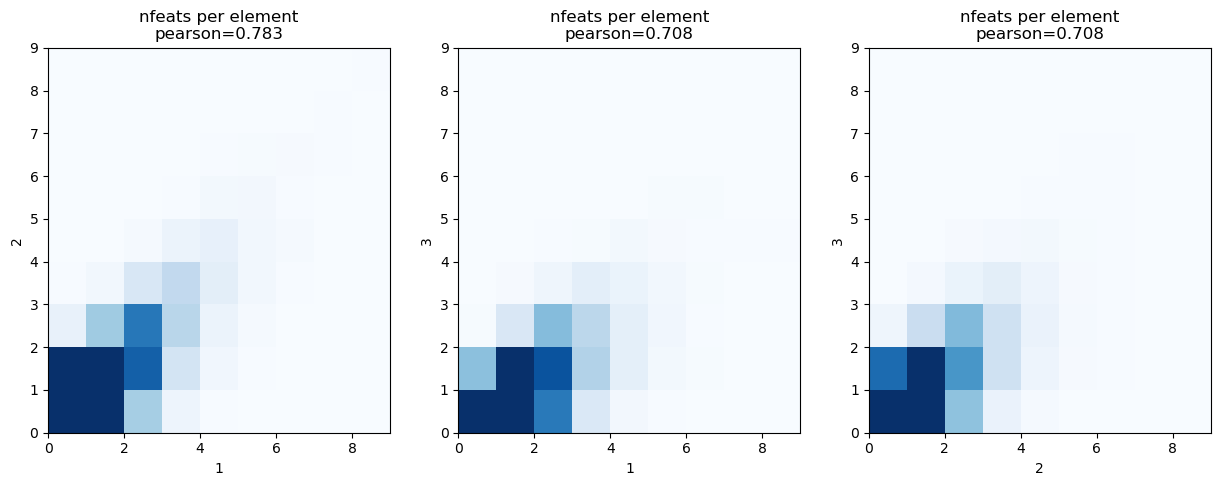

In [10]:

fig,ax=plt.subplots(1,3,figsize=(15,5))

d1,d2,d3=[rep2val[i] for i in [1,2,3]]

pears12=round(stats.pearsonr(d1,d2)[0],3)
pears13=round(stats.pearsonr(d1,d3)[0],3)
pears23=round(stats.pearsonr(d2,d3)[0],3)


ax[0].hist2d(d1,d2,bins=range(10),cmap='Blues',vmin=0,vmax=2e4)
ax[1].hist2d(d1,d3,bins=range(10),cmap='Blues',vmin=0,vmax=2e4)
ax[2].hist2d(d2,d3,bins=range(10),cmap='Blues',vmin=0,vmax=2e4)

ax[0].set_ylabel('2')
ax[1].set_ylabel('3')
ax[2].set_ylabel('3')

ax[0].set_xlabel('1')
ax[1].set_xlabel('1')
ax[2].set_xlabel('2')

ax[0].set_title(f'nfeats per element\npearson={pears12}')
ax[1].set_title(f'nfeats per element\npearson={pears13}')
ax[2].set_title(f'nfeats per element\npearson={pears23}')


# Reproducibility of syntax score

In [12]:
bDF['Ma-sum-nafill1-rep1']=bDF['Ma-sum-nafill1-rep1'].apply(lambda i: round(i))
bDF['Ma-sum-nafill1-rep2']=bDF['Ma-sum-nafill1-rep2'].apply(lambda i: round(i))
bDF['Ma-sum-nafill1-rep3']=bDF['Ma-sum-nafill1-rep3'].apply(lambda i: round(i))

In [13]:
rep2nfeat2alist={}
rep2synscore2alist={}
for rep in [1,2,3]:

    rep2nfeat2alist[rep]={}
    rep2synscore2alist[rep]={}
    for nfeat,wta,aba,synscore in zipdf(bDF,[f'numfeats-rep{rep}',
                                       f'wt-pool-sumR/sumD-{rep}-filtNa-Dnotnull-minActFilt0.15-log2-rescaled',
                                       f'abl-pool-sumR/sumD-{rep}-filtNa-Dnotnull-minActFilt0.15-log2-rescaled',
                                       f'Ma-sum-nafill1-rep{rep}']):

        
        
        valid=False
        if wta>1 and aba<0:
            valid=True # enhancer dep on gata and ets
            funclabel=1
        if wta<0:
            valid=True # inert element
            funclabel=0
        # otherwise, its active with abl>0 or unclassified

        if valid: 
            if nfeat not in rep2nfeat2alist[rep]:
                rep2nfeat2alist[rep][nfeat]=[]

            if synscore not in rep2synscore2alist[rep]:
                rep2synscore2alist[rep][synscore]=[]
            
            rep2nfeat2alist[rep][nfeat].append(funclabel)
            rep2synscore2alist[rep][synscore].append(funclabel)


feats1=set(rep2nfeat2alist[1].keys())
feats2=set(rep2nfeat2alist[2].keys())
feats3=set(rep2nfeat2alist[3].keys())
allfeats=feats1&feats2&feats3

rep2vals={}

for rep in [1,2,3]:
    rep2vals[rep]=[]
    
    for nfeat in allfeats:

        nactive=sum(rep2nfeat2alist[rep][nfeat])
        ntot=len(rep2nfeat2alist[rep][nfeat])
        
        rep2vals[rep].append(nactive/ntot)


feats1=set(rep2synscore2alist[1].keys())
feats2=set(rep2synscore2alist[2].keys())
feats3=set(rep2synscore2alist[3].keys())
allfeats=feats1&feats2&feats3

rep2vals2={}

for rep in [1,2,3]:
    rep2vals2[rep]=[]
    
    for nfeat in allfeats:

        nactive=sum(rep2synscore2alist[rep][nfeat])
        ntot=len(rep2synscore2alist[rep][nfeat])
        
        rep2vals2[rep].append(nactive/ntot)
        

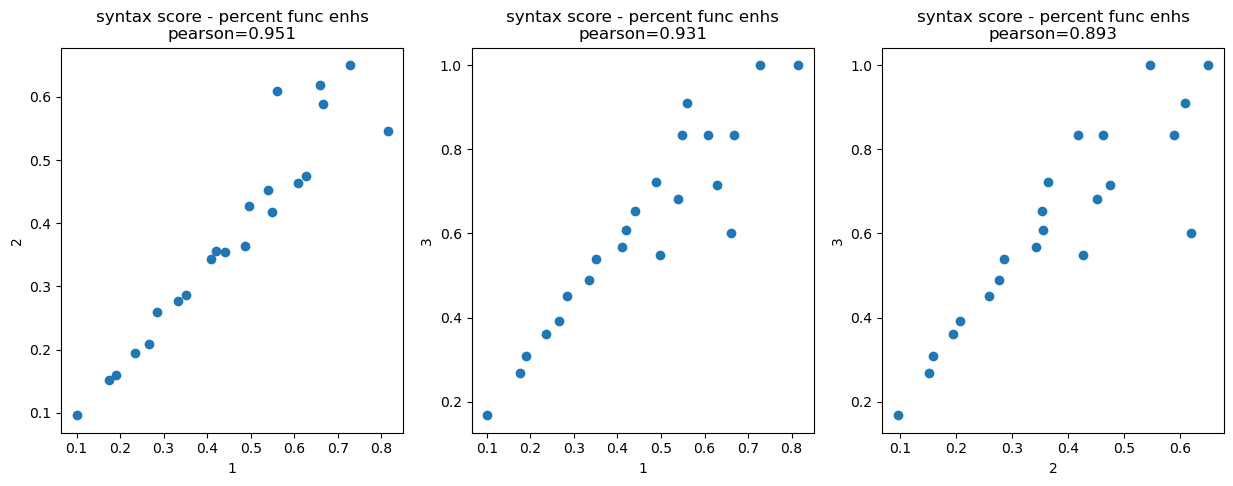

In [15]:

fig,ax=plt.subplots(1,3,figsize=(15,5))

d1,d2,d3=[rep2vals2[i] for i in [1,2,3]]

pears12=round(stats.pearsonr(d1,d2)[0],3)
pears13=round(stats.pearsonr(d1,d3)[0],3)
pears23=round(stats.pearsonr(d2,d3)[0],3)


ax[0].scatter(d1,d2)
ax[1].scatter(d1,d3)
ax[2].scatter(d2,d3)

ax[0].set_ylabel('2')
ax[1].set_ylabel('3')
ax[2].set_ylabel('3')

ax[0].set_xlabel('1')
ax[1].set_xlabel('1')
ax[2].set_xlabel('2')

ax[0].set_title(f'syntax score - percent func enhs\npearson={pears12}')
ax[1].set_title(f'syntax score - percent func enhs\npearson={pears13}')
ax[2].set_title(f'syntax score - percent func enhs\npearson={pears23}')

